# fastEIT — Parser Validation on Real Data

Proof-of-concept of the parsing pipeline on real files from a Dräger PulmoVista 500.

**Purpose**: verify that the `DragerBinParsers` correctly extract the data stored in real clinical
files and that the output objects are reliable. This notebook does **not** apply any
signal processing, no filters, no EIT reconstruction masks.
Raw parsed values are plotted directly to confirm parser correctness.

**Available files** (`src/fasteit/test_files/`):
- `patient01.bin`, `patient02.bin` - reconstructed EIT images (32×32 pixels per frame)
- `patient01.asc`, `patient02.asc` - continuous waveforms (PressurePod, global EIT, ventilator)
- `patient01.eit`, `patient02.eit` - raw transimpedance voltages (parser not yet implemented → skipped)

---

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fasteit.parsers.loader import load_data, load_many, load_folder

TEST_FILES = Path("../src/fasteit/test_files")
print("Available files:")
for f in sorted(TEST_FILES.iterdir()):
    print(f"  {f.name}  ({f.stat().st_size / 1_000_000:.1f} MB)")

Available files:
  HealthyLung.asc  (0.3 MB)
  HealthyLung.bin  (4.9 MB)
  HealthyLung.eit  (6.2 MB)
  patient01.asc  (2.9 MB)
  patient01.bin  (50.4 MB)
  patient01.eit  (63.2 MB)
  patient02.asc  (3.0 MB)
  patient02.bin  (53.2 MB)
  patient02.eit  (66.8 MB)


---

## 1. Single `.bin` file — reconstructed EIT images

`load_data()` auto-detects vendor and format and returns a `ReconstructedFrameData`.
The Dräger `.bin` file contains 32×32 pixel images already reconstructed by the PulmoVista firmware.
Timestamps are stored as **fractions of a day** (0.0 = midnight, 1.0 = 24 h).

In [2]:
rec = load_data(TEST_FILES / "patient01.bin")

print(f"Object type    : {type(rec).__name__}")
print(f"Vendor         : {rec.vendor}")
print(f"File format    : {rec.file_format}")
print(f"N frames       : {rec.n_frames}")
print(f"Sampling rate  : {rec.fs} Hz")
print(f"Duration       : {rec.n_frames / rec.fs:.1f} s  ({rec.n_frames / rec.fs / 60:.1f} min)")
print()
print(f"pixels shape   : {rec.pixels.shape}")
print(f"pixels min/max : {rec.pixels.min():.3f} / {rec.pixels.max():.3f}")
print()

# Fraction of day → seconds from start of recording
t_bin = (rec.timestamps - rec.timestamps[0]) * 86400
print(f"timestamps[0]  : {rec.timestamps[0]:.10f}  (fraction of day)")
print(f"t_bin[-1]      : {t_bin[-1]:.1f} s  ({t_bin[-1] / 60:.1f} min)")
print()
print("Detection metadata:")
for k in ("detected_vendor", "detected_extension", "detected_bin_format"):
    print(f"  {k}: {rec.metadata.get(k)}")

Object type    : ReconstructedFrameData
Vendor         : draeger
File format    : bin
N frames       : 11500
Sampling rate  : 50.0 Hz
Duration       : 230.0 s  (3.8 min)

pixels shape   : (11500, 32, 32)
pixels min/max : -7.729 / 28.530

timestamps[0]  : 0.7575696991  (fraction of day)
t_bin[-1]      : 230.0 s  (3.8 min)

Detection metadata:
  detected_vendor: draeger
  detected_extension: .bin
  detected_bin_format: Draeger_ext_4382


### 1a. EIT images — heatmap

Each frame is a 32×32 matrix.
> **Note**: no circular body mask or electrode overlay applied during parsing — raw pixel values only after draeger software exporting.

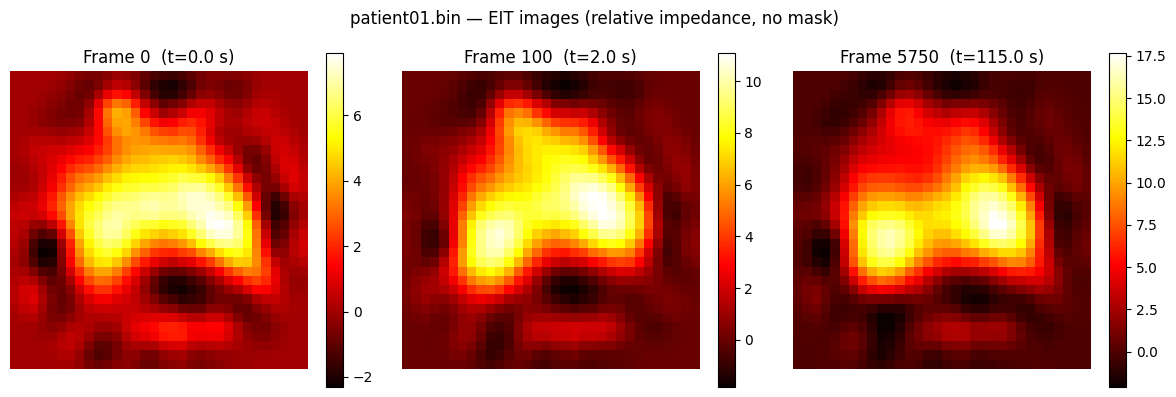

In [3]:
frame_idx = 100

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, idx in zip(axes, [0, frame_idx, rec.n_frames // 2]):
    im = ax.imshow(rec.pixels[idx], cmap="hot", origin="upper")
    ax.set_title(f"Frame {idx}  (t={t_bin[idx]:.1f} s)")
    ax.axis("off")
    plt.colorbar(im, ax=ax)
plt.suptitle("patient01.bin — EIT images (relative impedance, no mask)")
plt.tight_layout()
plt.show()

### 1b. Global EIT signal over time

Sum of all pixels per frame. Should show the breathing pattern.

> **Note**: unfiltered signal. Cardiac artifact not removed.

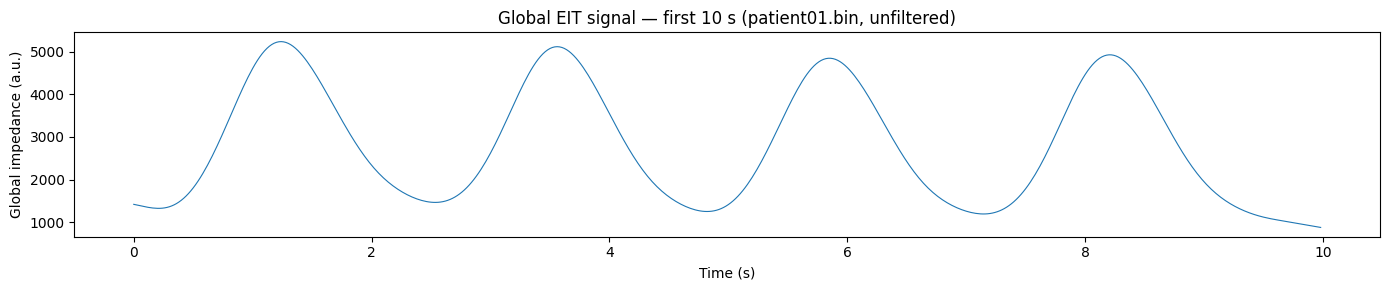

In [4]:
global_signal = rec.pixels.reshape(rec.n_frames, -1).sum(axis=1)

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(t_bin[:500], global_signal[:500], lw=0.8)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Global impedance (a.u.)")
ax.set_title("Global EIT signal — first 10 s (patient01.bin, unfiltered)")
plt.tight_layout()
plt.show()

---

## 2. Single `.asc` file — continuous waveforms

Returns a `ContinuousSignalData` with a `table` attribute (pandas DataFrame, ~69 columns).

The `time` column is also a **fraction of a day**, same convention as `.bin` timestamps.
This allows synchronising the two files by timestamp.

In [5]:
asc = load_data(TEST_FILES / "patient01.asc")
df = asc.table

print(f"Object type  : {type(asc).__name__}")
print(f"Vendor       : {asc.vendor}")
print(f"N frames     : {asc.n_frames}")
print(f"Sampling rate: {asc.fs} Hz")
print(f"time[0]      : {df['time'].iloc[0]:.10f}  (fraction of day)")
print()

num_df = df.select_dtypes(include=[float, int])
print("Channels with real data (non-NaN, std > 0.01):")
for col in num_df.columns:
    vals = num_df[col].dropna()
    if len(vals) > 100 and vals.std() > 0.01:
        print(f"  {col:35s}  min={vals.min():8.2f}  max={vals.max():8.2f}")

Object type  : ContinuousSignalData
Vendor       : draeger
N frames     : 11500
Sampling rate: 50 Hz
time[0]      : 0.7575696991  (fraction of day)

Channels with real data (non-NaN, std > 0.01):
  image                                min=    1.00  max=11500.00
  global                               min=   82.16  max= 5420.58
  local_1_x_16_y_29                    min=  -29.90  max=  475.47
  local_2_x_16_y_21                    min=   49.48  max= 2439.48
  local_3_x_16_y_13                    min=   32.64  max= 2390.43
  local_4_x_16_y_05                    min=  -37.14  max=  362.40
  minmax                               min=   -1.00  max=    1.00
  paw_pod_mbar                         min=   10.79  max=   39.82
  pes_pod_mbar                         min=    6.04  max=   21.84
  ptp_mbar                             min=   -4.41  max=   26.93
  pga_paux3_pod_mbar                   min=   -0.13  max=    0.20


### 2a. PressurePod waveforms + global EIT

Channels available in these files (PressurePod connected, ventilator not exported):
- `paw_pod_mbar` - `~Paw (Pod)` - airway pressure measured by the Pod
- `pes_pod_mbar` - `~Pes (Pod)` - esophageal pressure
- `ptp_mbar`     - `~Ptp`       - transpulmonary pressure
- `pga_paux3_pod_mbar` - `~Pga/Paux3 (Pod)` - gastric / auxiliary pressure
- `global`       - global EIT impedance (from `.asc`)

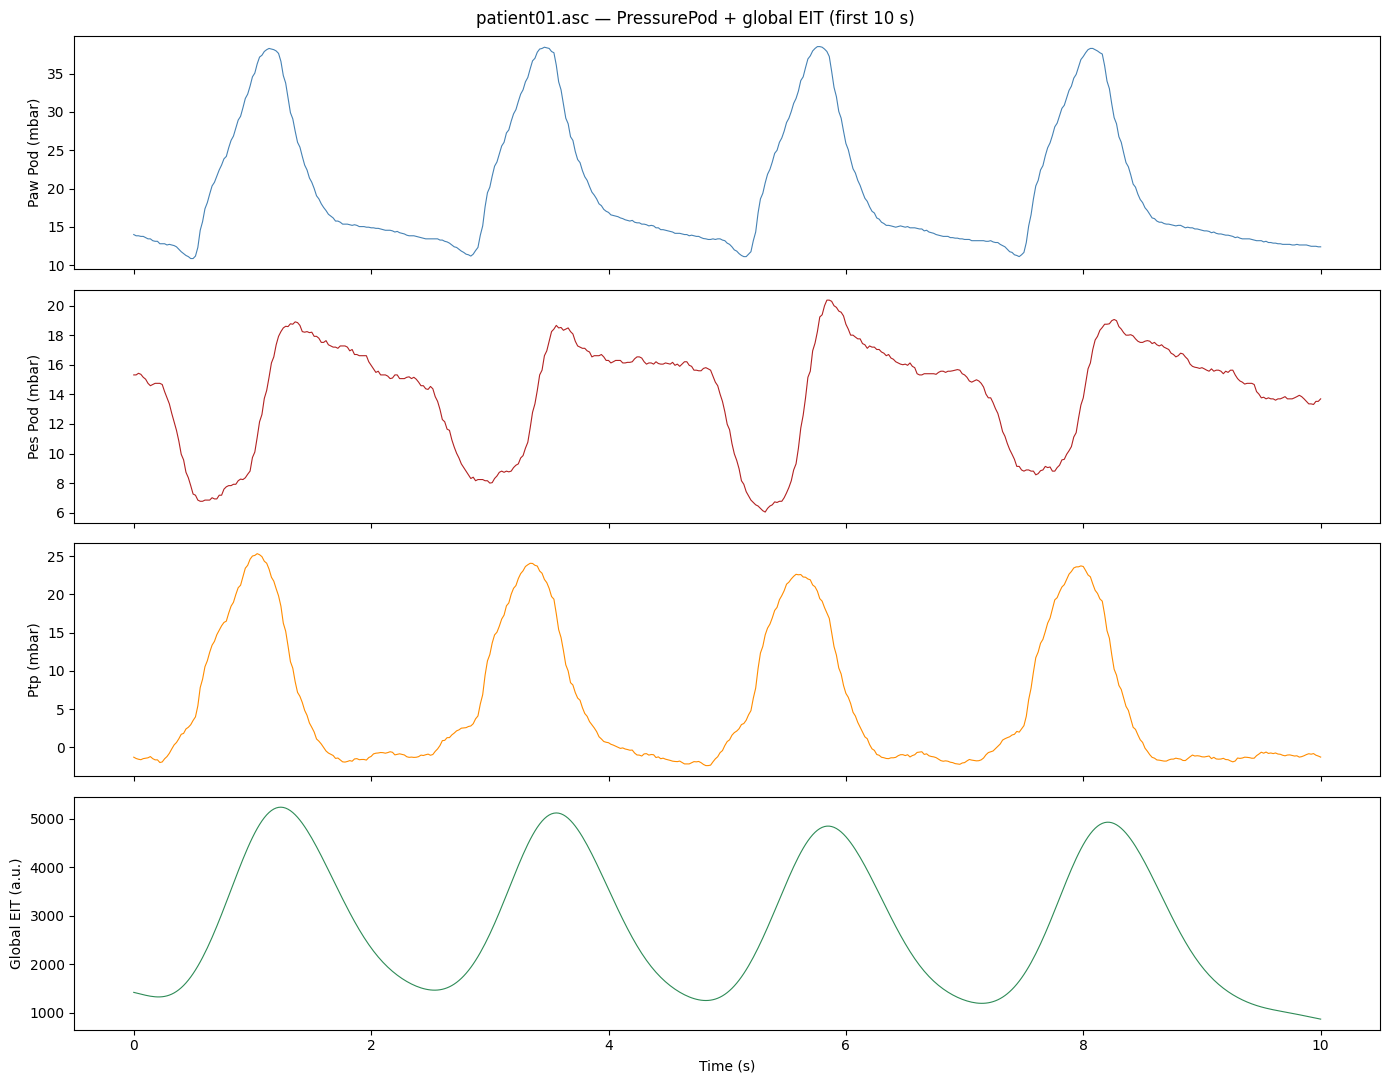

In [6]:
# Time axis: 'time' column (fraction of day) → seconds from start
t_asc = (df["time"] - df["time"].iloc[0]) * 86400

# First 10 s
mask = t_asc <= 10.0

fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

axes[0].plot(t_asc[mask], df.loc[mask, "paw_pod_mbar"], lw=0.8, color="steelblue")
axes[0].set_ylabel("Paw Pod (mbar)")

axes[1].plot(t_asc[mask], df.loc[mask, "pes_pod_mbar"], lw=0.8, color="firebrick")
axes[1].set_ylabel("Pes Pod (mbar)")

axes[2].plot(t_asc[mask], df.loc[mask, "ptp_mbar"], lw=0.8, color="darkorange")
axes[2].set_ylabel("Ptp (mbar)")

axes[3].plot(t_asc[mask], df.loc[mask, "global"], lw=0.8, color="seagreen")
axes[3].set_ylabel("Global EIT (a.u.)")
axes[3].set_xlabel("Time (s)")

plt.suptitle("patient01.asc — PressurePod + global EIT (first 10 s)")
plt.tight_layout()
plt.show()

---

## 2b. Global EIT: raw pixel sum (BIN) vs processed global (ASC)

Two ways to get a global EIT signal:

- **BIN raw sum** — `pixels.sum(axis=(1,2))`: sum of all 32×32 pixels, no mask, no filter.
- **ASC global** — the `global` column exported by the PulmoVista software

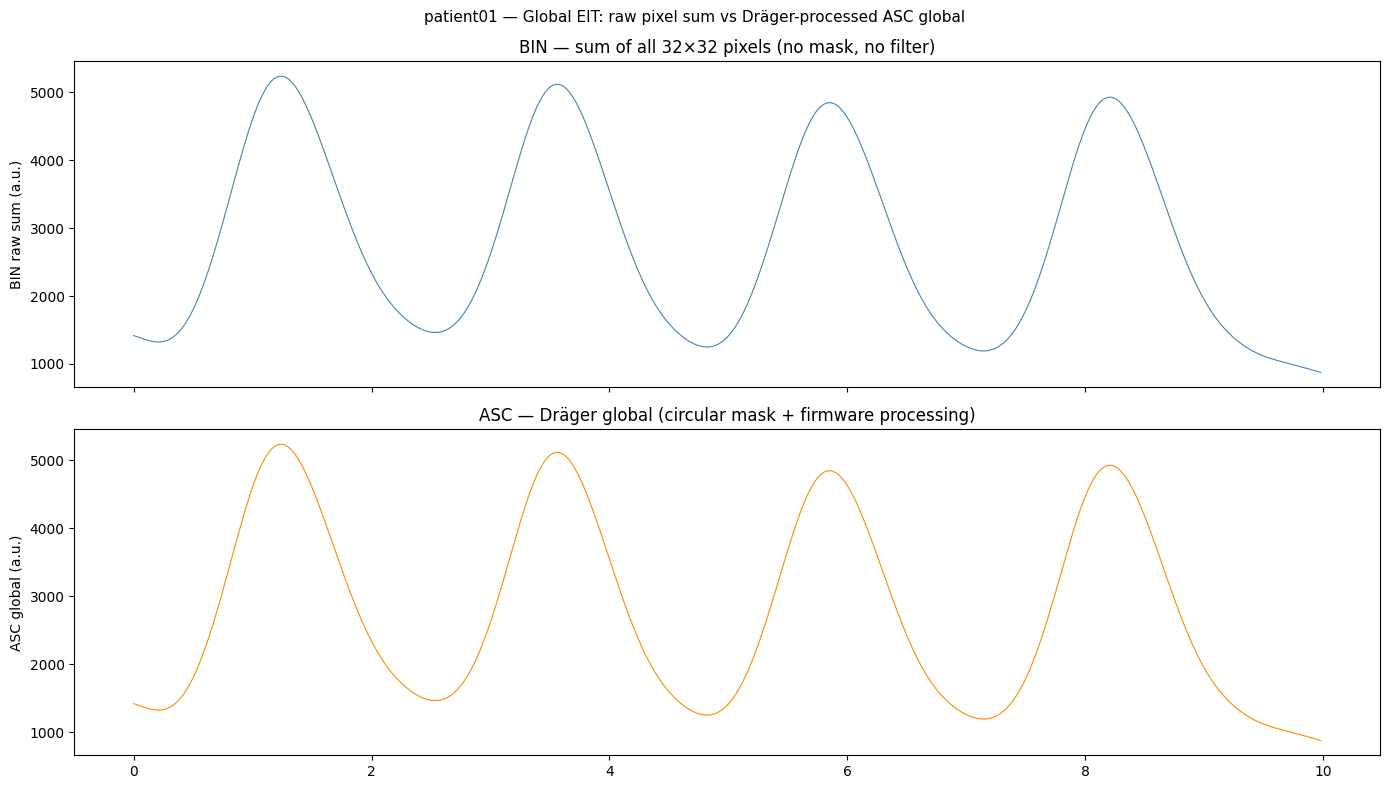

Pearson r (first 10 s): 1.0000
BIN raw  — mean: 2784.7  std: 1364.9
ASC global — mean: 2784.7  std: 1364.9


In [7]:
# Global from BIN: sum all 32×32 pixels per frame (no mask, no filter)
global_bin_raw = rec.pixels.sum(axis=(1, 2))

# Global from ASC: Dräger-processed (circular mask + firmware smoothing)
global_asc = df["global"].values

# Both are 50 Hz — use t_bin as time axis (same recording)
n_plot = 500  # first 10 s at 50 Hz
t = t_bin[:n_plot]

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: raw pixel sum
axes[0].plot(t, global_bin_raw[:n_plot], lw=0.8, color="steelblue")
axes[0].set_ylabel("BIN raw sum (a.u.)")
axes[0].set_title("BIN — sum of all 32×32 pixels (no mask, no filter)")

# Panel 2: ASC global
axes[1].plot(t, global_asc[:n_plot], lw=0.8, color="darkorange")
axes[1].set_ylabel("ASC global (a.u.)")
axes[1].set_title("ASC — Dräger global (circular mask + firmware processing)")

plt.suptitle("patient01 — Global EIT: raw pixel sum vs Dräger-processed ASC global", fontsize=11)
plt.tight_layout()
plt.show()

# Pearson correlation as a quantitative check
import numpy as np
r = np.corrcoef(global_bin_raw[:n_plot], global_asc[:n_plot])[0, 1]
print(f"Pearson r (first 10 s): {r:.4f}")
print(f"BIN raw  — mean: {global_bin_raw[:n_plot].mean():.1f}  std: {global_bin_raw[:n_plot].std():.1f}")
print(f"ASC global — mean: {global_asc[:n_plot].mean():.1f}  std: {global_asc[:n_plot].std():.1f}")

---

## 2c. Cross-check BIN vs ASC — PressurePod channels (both patients)

The Medibus fields in the `.bin` file and the columns in the `.asc` file must be
**numerically identical** frame-by-frame. The plot overlays ASC (solid colour) and
BIN (dashed black): if the channel names are correct, the curves overlap perfectly.


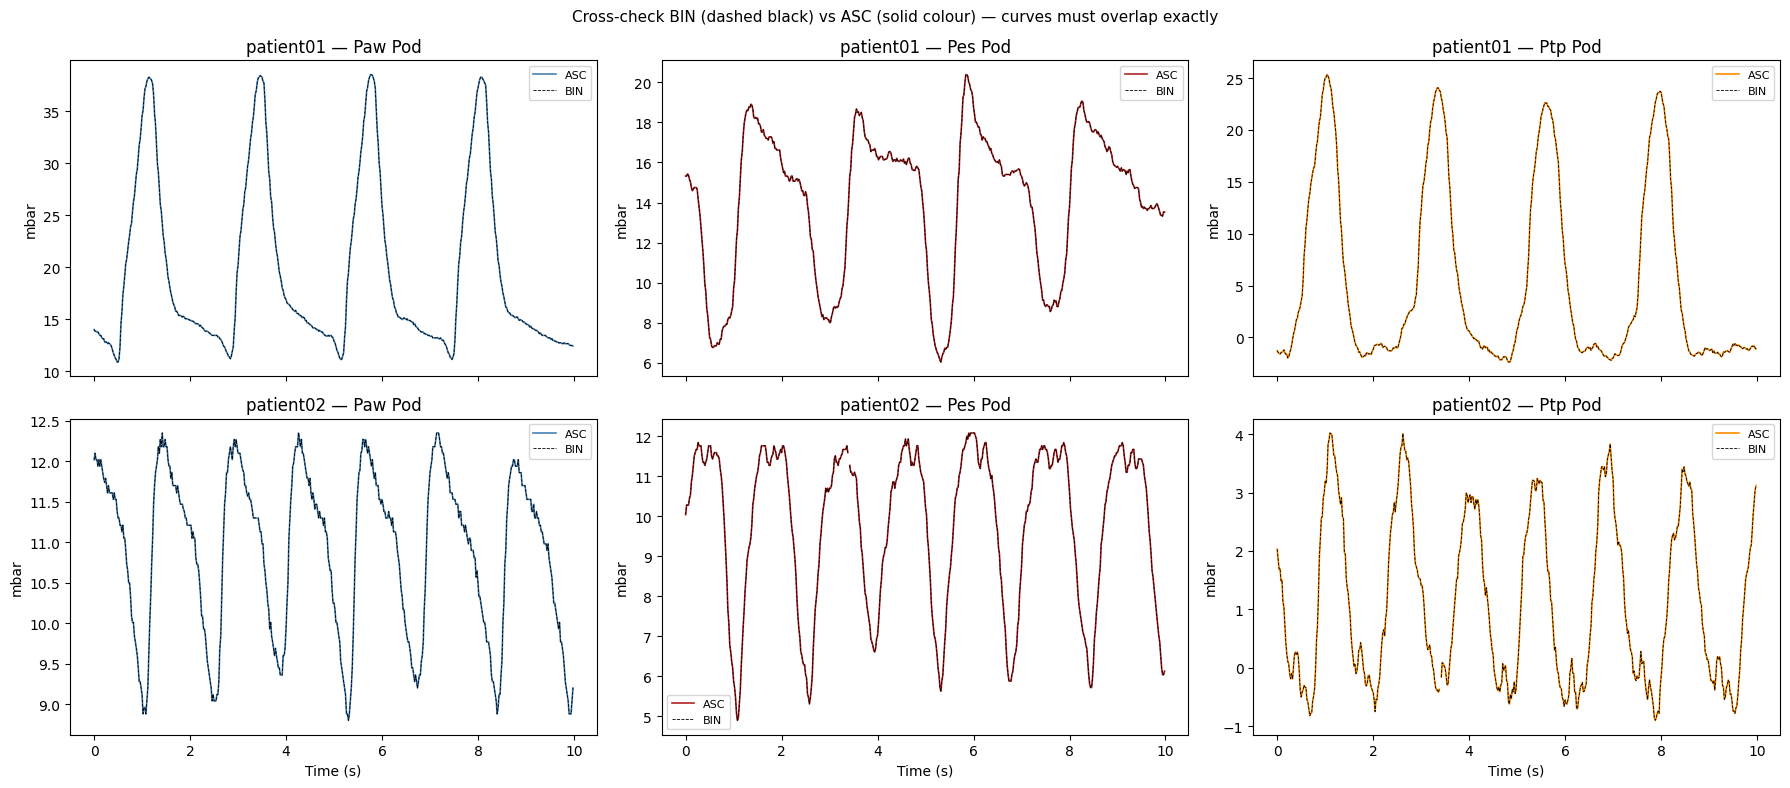

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=True)
fs = 50
n10 = int(10 * fs)
t = np.arange(n10) / fs

pod_channels = [
    ("paw_pod_mbar",       "airway_pressure_pod",         "Paw Pod",  "steelblue"),
    ("pes_pod_mbar",       "esophageal_pressure_pod",     "Pes Pod",  "firebrick"),
    ("ptp_mbar",           "transpulmonary_pressure_pod", "Ptp Pod",  "darkorange"),
]

for row, pt in enumerate(["patient01", "patient02"]):
    rec_pt = load_data(TEST_FILES / f"{pt}.bin")
    asc_pt = load_data(TEST_FILES / f"{pt}.asc")
    df_pt  = asc_pt.table

    for col, (asc_col, bin_col, label, color) in enumerate(pod_channels):
        asc_v = df_pt[asc_col].values[:n10]
        bin_v = rec_pt.aux_signals[bin_col][:n10]

        axes[row, col].plot(t, asc_v, lw=1.2, color=color, label="ASC")
        axes[row, col].plot(t, bin_v, lw=0.6, ls="--", color="black", label="BIN")
        axes[row, col].set_title(f"{pt} — {label}")
        axes[row, col].set_ylabel("mbar")
        axes[row, col].legend(fontsize=8)

for ax in axes[1]:
    ax.set_xlabel("Time (s)")

plt.suptitle(
    "Cross-check BIN (dashed black) vs ASC (solid colour) — curves must overlap exactly",
    fontsize=11,
)
plt.tight_layout()
plt.show()

---

## 3. Multi-file — `load_many()`

`load_many()` takes a list of paths and returns a list of `BaseData` objects.
Vendor and format can be mixed — each file is parsed independently.

In [9]:
recordings = load_many([
    TEST_FILES / "HealthyLung.bin",
    TEST_FILES / "patient01.bin",
    TEST_FILES / "patient02.bin",
    TEST_FILES / "HealthyLung.asc",
    TEST_FILES / "patient01.asc",
    TEST_FILES / "patient02.asc",
])

for r in recordings:
    print(f"{type(r).__name__:<26}  vendor={r.vendor:<8}  n_frames={r.n_frames:<6}  {Path(r.filename).name}")

ReconstructedFrameData      vendor=draeger   n_frames=1118    HealthyLung.bin
ReconstructedFrameData      vendor=draeger   n_frames=11500   patient01.bin
ReconstructedFrameData      vendor=draeger   n_frames=12150   patient02.bin
ContinuousSignalData        vendor=draeger   n_frames=1118    HealthyLung.asc
ContinuousSignalData        vendor=draeger   n_frames=11500   patient01.asc
ContinuousSignalData        vendor=draeger   n_frames=12150   patient02.asc


---

## 4. Entire folder — `load_folder()`

`load_folder()` scans all files in alphabetical order.
Files with no registered parser (`.eit`) are **skipped** with a warning on stderr.
All other files are loaded without interrupting the loop.

In [10]:
import io, contextlib

stderr_capture = io.StringIO()
with contextlib.redirect_stderr(stderr_capture):
    all_recs = load_folder(TEST_FILES)

warnings = stderr_capture.getvalue()
if warnings:
    print("Skipped (no parser registered):")
    for line in warnings.strip().splitlines():
        print(f"  {line}")
    print()

print(f"Successfully loaded: {len(all_recs)} / 6 files")
for r in all_recs:
    print(f"  {type(r).__name__:<26}  {Path(r.filename).name}")

Skipped (no parser registered):
  [load_folder] skipping 'HealthyLung.eit': detect_vendor_from_eit_header() not yet implemented. 
  [load_folder] skipping 'patient01.eit': detect_vendor_from_eit_header() not yet implemented. 
  [load_folder] skipping 'patient02.eit': detect_vendor_from_eit_header() not yet implemented.

Successfully loaded: 6 / 6 files
  ContinuousSignalData        HealthyLung.asc
  ReconstructedFrameData      HealthyLung.bin
  ContinuousSignalData        patient01.asc
  ReconstructedFrameData      patient01.bin
  ContinuousSignalData        patient02.asc
  ReconstructedFrameData      patient02.bin
